In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import cupy as cp
from scipy.signal import find_peaks
from skimage.draw import polygon
from skimage.filters import threshold_otsu
from skimage.morphology import closing, square
import re
import os

In [2]:

def load_all_artifacts_from_folder(base_path, pattern, run, data_type, folder_name):
    """
    Automatically discover and load all artifact files from a folder
    
    Parameters:
    -----------
    base_path : str or Path
        Base directory path
    view : int
        View number
    run : int
        Run number  
    data_type : str
        'measurement_updates' or 'diffusion_updates' or other data types
    folder_name : str
        Name of the experiment folder (e.g., "Dps_24_400_steps_two_images_2_last_image")
    
    Returns:
    --------
    dict
        Dictionary with artifact_ids as keys and loaded data as values
        {
            'artifact_1-073': numpy.ndarray,
            'artifact_1-054': numpy.ndarray,
            ...
        }
    """
    
    # Construct folder path
    folder_path = Path(base_path) / folder_name / f"run_{run}"
    
    if not folder_path.exists():
        print(f"Folder not found: {folder_path}")
        return {}
    
    # Get all files in the folder
    files = os.listdir(folder_path)
    
    # Pattern to match artifact files
    # Matches: artifact_1-073_measurement_updates.npy, artifact_1-054_diffusion_updates.npy, etc.
    # pattern = rf"({pattern}[\d\-]+)_{re.escape(data_type)}\.npy$"
    
    artifact_data = {}
    artifact_ids = set()
    suffix = f"_{data_type}.npy"
    # Find all artifact IDs
    for file in files:
        if file.startswith(pattern) and file.endswith(suffix):
            # Ensure the filename is longer than the suffix to avoid empty IDs
            if len(file) > len(suffix):
                artifact_id = file[:-len(suffix)]
                artifact_ids.add(artifact_id)
    
    
    print(f"Found {len(artifact_ids)} artifacts in {folder_path}")
    print(f"Artifact IDs: {sorted(list(artifact_ids))}")
    
    # Load data for each artifact
    for artifact_id in sorted(artifact_ids):
        file_path = folder_path / f"{artifact_id}_{data_type}.npy"
        
        if file_path.exists():
            try:
                data = np.load(file_path)
                artifact_data[artifact_id] = data
                print(f"✓ Loaded {artifact_id}: shape {data.shape}")
            except Exception as e:
                print(f"✗ Error loading {artifact_id}: {e}")
                artifact_data[artifact_id] = None
        else:
            print(f"✗ File not found: {file_path}")
            artifact_data[artifact_id] = None
    
    return artifact_data
def average_artifacts_over_runs(base_path, pattern, runs, data_type, folder_names):
    """
    Load artifacts from multiple folders and runs, then average over runs
    
    Parameters:
    -----------
    base_path : str
        Base directory path
    view : int
        View number
    runs : list
        List of run numbers (e.g., [1, 2, 3])
    data_type : str
        'measurement_updates' or other data types
    folder_names : list
        List of folder names to load from
    
    Returns:
    --------
    numpy.ndarray
        Averaged data across all runs and folders
    """
    
    all_run_data = []  # Store data from each run
    
    for run in runs:
        run_total = None
        
        # Sum all artifacts from all folders for this run
        for folder_name in folder_names:
            artifacts = load_all_artifacts_from_folder(base_path, pattern, run, data_type, folder_name)
            
            # Sum all artifacts from this folder
            for arr in artifacts.values():
                # if arr is not None:
                #     if run_total is None:
                #         run_total = arr.copy()
                #     else:
                #         run_total += arr
                all_run_data.append(arr)
        
        # if run_total is not None:
        #     all_run_data.append(run_total)
        #     print(f"✓ Processed run {run}: shape {run_total.shape}")
        # else:
        #     print(f"✗ No data found for run {run}")
    
    if len(all_run_data) == 0:
        print("No valid data found across any runs")
        return None
    
    # Average across all runs
    averaged_data = np.mean(all_run_data, axis=0)
    print(f"Averaged across {len(all_run_data)} runs: final shape {averaged_data.shape}")
    
    return np.array(all_run_data)

# Usage - replace your existing code with:
base_path = "/data/akheirandish3/PaDIS_results/"
runs = [1]  # Runs to average over
folder_names = [
    # "Dps_24_calibration_50_dark",
    # "Dps_24_calibration_200",
    # "Dps_24_calibration_0_200_5_samples",
    # "Dps_24_calibration_200_6samples",
    # "Dps_24_calibration_0_100_3_samples",
    # "Dps_24_validation",
    # "Dps_24_training_calibration_data"
    "Dps_24_calibration_aligned_new"
    # "Dps_24_calibration_aligned_start_artifact_5_sample"

]
pattern = ""

# Load measurement updates from all folders
id_measurement = {}
for folder_name in folder_names:
    artifacts = load_all_artifacts_from_folder(
        base_path=base_path,
        pattern=pattern,
        run=1,
        data_type="measurement_updates",
        folder_name=folder_name
    )
    # Merge artifacts from this folder into the main dictionary
    id_measurement.update(artifacts)
# id_measurement.update(artifacts)
# Load sigma for normalization (from run 1)
print("Loading sigma for normalization...")

sigma_norm = load_all_artifacts_from_folder(base_path, pattern, 1, "sigma_values", folder_names[0])
one_sigma = next(iter(sigma_norm.values()), None)
# id_measurement.shape

Found 705 artifacts in /data/akheirandish3/PaDIS_results/Dps_24_calibration_aligned_new/run_1
Artifact IDs: ['0001_21_0173_mean', '0002_18_0011_mean', '0003_25_0122_mean', '0004_24_0122_mean', '0005_24_0033_mean', '0006_22_0031_mean', '0007_21_0136_mean', '0008_5_0056_mean', '0009_21_0073_mean', '0010_29_0031_mean', '0011_18_0039_mean', '0012_18_0031_mean', '0013_21_0100_mean', '0014_24_0014_mean', '0015_24_0071_mean', '0016_30_0158_mean', '0017_18_0017_mean', '0018_8_0026_mean', '0019_23_0173_mean', '0020_5_0055_mean', '0021_29_0021_mean', '0022_24_0021_mean', '0023_29_0142_mean', '0024_25_0135_mean', '0025_16_0026_mean', '0026_23_0012_mean', '0027_29_0034_mean', '0028_27_0040_mean', '0029_25_0134_mean', '0030_22_0096_mean', '0031_24_0000_mean', '0032_27_0025_mean', '0033_21_0135_mean', '0034_21_0096_mean', '0035_27_0203_mean', '0036_21_0113_mean', '0037_27_0117_mean', '0038_27_0055_mean', '0039_25_0079_mean', '0040_18_0086_mean', '0041_29_0184_mean', '0042_5_0019_mean', '0043_21_0228

In [3]:
import cv2
def mask_by_body_shape(img: np.ndarray,
                       mode: str = "black_inside",
                       use_hull: bool = False,
                       open_kernel: tuple = (5,5),
                       erode_iters: int = 0,
                       min_area_ratio: float = 0.01):
    """
    Create a mask from the largest connected shape (body) and apply it.

    Args:
        img            : uint8 grayscale or BGR image.
        mode           : "black_inside" to zero the inside; "keep_inside" to zero outside.
        use_hull       : if True, use convex hull of the largest contour (smoother outline).
        open_kernel    : kernel size for morphological open to denoise before contouring.
        erode_iters    : optional erosion of the mask to shrink it slightly.
        min_area_ratio : discard tiny artifacts; min area relative to image area.

    Returns:
        masked         : image with mask applied (uint8, same shape as input).
        mask           : uint8 mask (255 = inside shape, 0 = outside).
        info           : dict with contour area and bounding box.
    """
    g = img
    if img.ndim == 3:
        g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # binarize and clean
    _ , th = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, open_kernel)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)

    # take largest external contour above area threshold
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        raise ValueError("No contours found.")
    H, W = g.shape[:2]
    area_min = min_area_ratio * (H * W)
    cnts = [c for c in cnts if cv2.contourArea(c) >= area_min]
    if not cnts:
        raise ValueError("No sufficiently large contour found.")
    c = max(cnts, key=cv2.contourArea)

    if use_hull:
        c = cv2.convexHull(c)

    mask = np.zeros(g.shape, dtype=np.uint8)
    cv2.drawContours(mask, [c], -1, 255, thickness=-1)
    if erode_iters > 0:
        mask = cv2.erode(mask, kernel, iterations=erode_iters)

    # apply mask
    if img.ndim == 2:
        out = img.copy()
        if mode == "black_inside":
            out[mask > 0] = 0
        elif mode == "keep_inside":
            out[mask == 0] = 0
        else:
            raise ValueError("mode must be 'black_inside' or 'keep_inside'")
    else:
        out = img.copy()
        if mode == "black_inside":
            out[mask > 0] = 0
        elif mode == "keep_inside":
            out[mask == 0] = 0
        else:
            raise ValueError("mode must be 'black_inside' or 'keep_inside'")

    x, y, w, h = cv2.boundingRect(c)
    info = {"area": float(cv2.contourArea(c)), "bbox": (x, y, w, h)}
    return out, mask, info



In [4]:
from scipy.stats import gaussian_kde, norm
from sklearn.mixture import GaussianMixture
from scipy.stats import lognorm
# from scipy.stats import frechet_r
from scipy.stats import weibull_min
from scipy.stats import levy

In [ ]:
def compute_patch_statistics_per_position(patch_norm_results): #origin one
    """
    Compute summary statistics for each individual patch position across all artifacts.
    
    Parameters:
    -----------
    patch_norm_results : dict
        Results from analyze_patch_norm_distributions
    
    Returns:
    --------
    dict
        Statistics for each patch size, where each patch size contains statistics
        for each individual patch position
    """
    patch_sizes = patch_norm_results['patch_sizes']
    all_artifacts = patch_norm_results['artifacts']
    
    position_stats = {}
    
    for patch_size in patch_sizes:
        # print(f"Processing patch size {patch_size}")
        
        # Determine grid dimensions for this patch size
        # Assuming 256x256 images
        H, W = 256, 256
        num_patches_h = H // patch_size
        num_patches_w = W // patch_size
        total_patches = num_patches_h * num_patches_w
        
        # print(f"  Grid: {num_patches_h}×{num_patches_w} = {total_patches} patches")
        
        # Initialize storage for each patch position
        patch_position_data = [[] for _ in range(total_patches)]
        
        # Collect data from all artifacts for each patch position
        for artifact_id, artifact_data in all_artifacts.items():
            if patch_size in artifact_data['patch_norms']:
                patch_norms = artifact_data['patch_norms'][patch_size]
                
                # Each patch_norms array should have exactly total_patches elements
                if len(patch_norms) == total_patches:
                    for pos in range(total_patches):
                        patch_position_data[pos].append(patch_norms[pos])
                else:
                    print(f"  Warning: {artifact_id} has {len(patch_norms)} patches, expected {total_patches}")
        
        # Compute statistics for each patch position
        position_stats[patch_size] = {
            'grid_shape': (num_patches_h, num_patches_w),
            'patch_positions': {}
        }
        
        for pos in range(total_patches):
            if patch_position_data[pos]:  # If we have data for this position
                pos_data = np.array(patch_position_data[pos])
                # print(f"  Patch position {pos} has {(pos_data).shape} samples")
                # Convert linear position to 2D coordinates
                row = pos // num_patches_w
                col = pos % num_patches_w
                
                position_stats[patch_size]['patch_positions'][(row, col)] = {
                    'mean': (np.mean(pos_data)),
                    'std': np.std(pos_data),
                    'median': np.median(pos_data),
                    'min': np.min(pos_data),
                    'max': np.max(pos_data),
                    'q25': np.percentile(pos_data, 25),
                    'q75': np.percentile(pos_data, 75),
                    'count': len(pos_data),
                    'all_values': pos_data
                }
            else:
                # Convert linear position to 2D coordinates
                row = pos // num_patches_w
                col = pos % num_patches_w
                position_stats[patch_size]['patch_positions'][(row, col)] = None
    
    return position_stats


def compute_patch_statistics_per_position_1(patch_norm_results):
    """
    Compute summary statistics for each individual patch position across all artifacts.
    This version is vectorized for performance.
    """
    patch_sizes = patch_norm_results['patch_sizes']
    all_artifacts = patch_norm_results['artifacts']
    num_artifacts = len(all_artifacts)
    
    position_stats = {}
    
    for patch_size in patch_sizes:
        H, W = 256, 256
        num_patches_h = H // patch_size
        num_patches_w = W // patch_size
        
        # Pre-allocate a 3D array: (num_artifacts, num_patches_h, num_patches_w)
        # Use np.nan to handle cases where an artifact might be missing this patch size
        all_patch_norms_grid = np.full((num_artifacts, num_patches_h, num_patches_w), np.nan)

        for i, (artifact_id, artifact_data) in enumerate(all_artifacts.items()):
            if patch_size in artifact_data['patch_norms']:
                patch_norms = artifact_data['patch_norms'][patch_size]
                if patch_norms.size == num_patches_h * num_patches_w:
                    all_patch_norms_grid[i, :, :] = patch_norms.reshape(num_patches_h, num_patches_w)

        # Compute statistics along the artifact axis (axis=0) in a single shot
        with np.errstate(divide='ignore', invalid='ignore'): # Suppress warnings for all-NaN slices
            mean_grid = np.nanmean(all_patch_norms_grid, axis=0)
            std_grid = np.nanstd(all_patch_norms_grid, axis=0)
            median_grid = np.nanmedian(all_patch_norms_grid, axis=0)
            min_grid = np.nanmin(all_patch_norms_grid, axis=0)
            max_grid = np.nanmax(all_patch_norms_grid, axis=0)
            q25_grid = np.nanpercentile(all_patch_norms_grid, 25, axis=0)
            q75_grid = np.nanpercentile(all_patch_norms_grid, 75, axis=0)
        
        # Count non-NaN values for each patch position
        count_grid = np.sum(~np.isnan(all_patch_norms_grid), axis=0)

        position_stats[patch_size] = {
            'grid_shape': (num_patches_h, num_patches_w),
            'stat_grids': {
                'mean': mean_grid,
                'std': std_grid,
                'median': median_grid,
                'min': min_grid,
                'max': max_grid,
                'q25': q25_grid,
                'q75': q75_grid,
                'count': count_grid
            },
            # Keep all values for percentile calculations in the next step
            'all_values_grid': all_patch_norms_grid 
        }
        
    return position_stats
def compare_patch_positions_ood_vs_id_1(ood_results, id_results, patch_sizes, flag = True, percentile_treshold=90, mask = None):
    """
    Compare patch statistics between OOD and ID data for each patch position.
    This version is vectorized and includes log-normal fitting for outliers.
    """
    comparison_results = {}
    
    for patch_size in patch_sizes:
        if patch_size not in ood_results or patch_size not in id_results:
            continue

        ood_stats = ood_results[patch_size]
        id_stats = id_results[patch_size]
        grid_shape = ood_stats['grid_shape']
        num_patches_h, num_patches_w = grid_shape

        # --- Extract stat grids ---
        # The vectorized compute_patch_statistics_per_position should return single-artifact stats correctly
        ood_mean_grid = ood_stats['stat_grids']['mean']
        id_mean_grid = id_stats['stat_grids']['mean']
        id_std_grid = id_stats['stat_grids']['std']
        id_all_values = id_stats['all_values_grid'] # Shape: (num_id_artifacts, H, W)

        # --- Vectorized Calculations ---
        with np.errstate(divide='ignore', invalid='ignore'):
            mean_diff = ood_mean_grid - id_mean_grid
            z_score = np.abs(mean_diff / (id_std_grid + 1e-8))

            # --- GMM/Log-Norm Z-Score Calculation (Vectorized) ---
            # Count how many ID values are >= OOD mean for each patch
            num_id_samples = id_stats['stat_grids']['count']
            # Ensure num_id_samples is not zero to avoid division errors
            valid_counts = num_id_samples > 0
            
            # Calculate empirical probability 't'
            counts = np.sum(id_all_values >= ood_mean_grid[np.newaxis, :, :], axis=0)
            t = np.full(grid_shape, 1.0) # Default to 1 if no samples
            t[valid_counts] = counts[valid_counts] / (num_id_samples[valid_counts] + 1)

            # Initialize gmm_z_score from the empirical 't'
            gmm_z_score = -1 * np.log(t + 1e-12)

            # --- Handle t=0 cases by fitting a log-normal distribution ---
            # Find patch positions where the OOD value is an outlier (t=0)
            # and where there are enough ID samples to fit a distribution.
            outlier_mask = (t == 0) & (num_id_samples > 5) # Need a few samples to fit
            outlier_indices = np.argwhere(outlier_mask)

            for h, w in outlier_indices:
                # Extract the 1D array of ID values for this specific patch
                patch_id_data = id_all_values[:, h, w]
                # Remove NaNs which might exist if some artifacts didn't have this patch size
                patch_id_data = patch_id_data[~np.isnan(patch_id_data)]
                
                if patch_id_data.size > 5: # Double-check after NaN removal
                    try:
                        # Fit a log-normal distribution to the ID data
                        shape, loc, scale = lognorm.fit(patch_id_data, floc=0)
                        
                        # Estimate the probability using the survival function (1 - CDF)
                        # This gives P(X >= x), which is what 't' was estimating
                        estimated_t = lognorm.sf(ood_mean_grid[h, w], shape, loc=loc, scale=scale)
                        
                        # Update the gmm_z_score for this specific patch
                        gmm_z_score[h, w] = -1 * np.log(estimated_t + 1e-12)
                    except Exception:
                        # If fitting fails, keep the high fallback value
                        gmm_z_score[h, w] = -1 * np.log(1e-12)

        # --- Masking ---
        valid_positions = (id_stats['stat_grids']['count'] > 0) & (ood_stats['stat_grids']['count'] > 0)
        if flag:
            y, x = np.ogrid[:num_patches_h, :num_patches_w]
            center_y, center_x = (num_patches_h - 1) / 2, (num_patches_w - 1) / 2
            circular_mask = (x - center_x)**2 + (y - center_y)**2 <= 0.75 * (num_patches_w / 2)**2
            valid_positions &= circular_mask
        
        if mask is not None:
            # Downsample the body mask to patch resolution
            patch_mask = cv2.resize(mask, (num_patches_w, num_patches_h), interpolation=cv2.INTER_NEAREST) > 0
            valid_positions &= patch_mask

        comparison_results[patch_size] = {
            'grid_shape': grid_shape,
            'summary_grids': {
                'mean_ratio': ood_mean_grid / (id_mean_grid + 1e-8),
                'mean_diff': mean_diff,
                'gmm_z_score': gmm_z_score,
                'z_score': z_score,
                'ood_mean': ood_mean_grid,
                'id_mean': id_mean_grid,
                'ood_std': ood_stats['stat_grids']['std'],
                'id_std': id_std_grid,
                'valid_positions': valid_positions
            }
        }
            
    return comparison_results

def compare_patch_positions_ood_vs_id(ood_results, id_results, patch_sizes, flag = True, percentile_treshold=90, mask = None):
    """
    Compare patch statistics between OOD and ID data for each patch position.
    
    Parameters:
    -----------
    ood_results : dict
        Position statistics for OOD data
    id_results : dict
        Position statistics for ID data
    patch_sizes : list
        List of patch sizes to analyze
    
    Returns:
    --------
    dict
        Comparison results for each patch size and position
    """
    comparison_results = {}
    
    for patch_size in patch_sizes:
        if patch_size in ood_results and patch_size in id_results:
            # print(f"Comparing patch size {patch_size}")
            
            grid_shape = ood_results[patch_size]['grid_shape']
            num_patches_h, num_patches_w = grid_shape
            
            comparison_results[patch_size] = {
                'grid_shape': grid_shape,
                'position_comparisons': {},
                'summary_grids': {
                    'mean_ratio': np.zeros(grid_shape),
                    'mean_diff': np.zeros(grid_shape),
                    'gmm_z_score': np.zeros(grid_shape),
                    'z_score': np.zeros(grid_shape),
                    'separation_score': np.zeros(grid_shape),
                    'ood_mean': np.zeros(grid_shape),
                    'id_mean': np.zeros(grid_shape),
                    'ood_std': np.zeros(grid_shape),
                    'id_std': np.zeros(grid_shape),
                    'valid_positions': np.zeros(grid_shape, dtype=bool)
                }
            }
            
            for row in range(num_patches_h):
                for col in range(num_patches_w):
                    if flag and (row-num_patches_h/2)**2+(col-num_patches_w/2)**2 > 0.75*num_patches_w**2/4:
                        continue  # within circular mask
                    pos_key = (row, col)
                    
                    ood_stats = ood_results[patch_size]['patch_positions'].get(pos_key)
                    id_stats = id_results[patch_size]['patch_positions'].get(pos_key)

                    # print(ood_stats['all_values'].shape, id_stats['all_values'].shape)
                    if ood_stats is not None and id_stats is not None:
                        # Compute comparison metrics
                        mean_ratio = ood_stats['mean'] / (id_stats['mean'] + 1e-8)
                        mean_diff = (ood_stats['mean'] - id_stats['mean'])
                        std_ratio = ood_stats['std'] / (id_stats['std'] + 1e-8)
                        
                        # Separation score (normalized difference)
                        pooled_std = np.sqrt((ood_stats['std']**2 + id_stats['std']**2) / 2)
                        # print("Percentile is: ", np.percentile(id_stats['all_values'], 90))
                        separation_score = np.percentile(ood_stats['all_values'], 50) - np.percentile(id_stats['all_values'], percentile_treshold)
                        separation_score = (ood_stats['mean'] > np.percentile(id_stats['all_values'], percentile_treshold)) #or (ood_stats['mean'] < np.percentile(id_stats['all_values'], 100-percentile_treshold))
                        # hist, bin_edges = np.histogram(id_stats["all_values"], bins=50, density=True) 
                        # # find which bin the ood_mean falls into
                        # bin_index = np.digitize(ood_stats['mean'], bin_edges) - 1
                        # prob_density = hist[bin_index] if 0 <= bin_index < len(hist) else 0.0
                        # separation_score = -np.log(prob_density + 1e-8)
                        
                                                # --- GMM-based Z-score calculation ---
                        # z_score = mean_diff / (id_stats['std'] + 1e-8)
                        # gmm_z_score = 0.0
                        # for ood_data in ood_stats['all_values']:
                        #     t = np.sum(id_stats['all_values'] < ood_data) / len(id_stats['all_values'])
                        #     gmm_z_score += 0.5 - min(t, 1-t)
                        # print(id_stats['all_values'])
                        t = np.sum(id_stats['all_values'] >= ood_stats['mean']) / (len(id_stats['all_values'])+1)
                        second_max = np.sort(id_stats['all_values'])
                        # if t == 0:
                        #     t = 2/(len(id_stats['all_values'])+1)*np.exp(-1*np.log(2)/(second_max[-1]-second_max[-2]+1e-4)*(ood_stats['mean']-second_max[-2]))
                        shape, loc, scale = lognorm.fit(id_stats['all_values'], floc=0)
                        # shape, loc, scale = weibull_min.fit(id_stats['all_values'])  
                        # loc, scale = levy.fit(id_stats['all_values'])
                        if t == 0:
                            # t = norm.sf(ood_stats['mean'], loc=id_stats['mean'], scale=id_stats['std'])
                            t = lognorm.cdf(ood_stats['mean'], shape, loc=loc, scale=scale)
                            t = 1-t
                            # t = weibull_min.pdf(ood_stats['mean'], shape, loc=loc, scale=scale)
                            # t = levy.pdf(ood_stats['mean'], loc=loc, scale=scale)
                        # if t > 1:
                        #     print(ood_stats['mean'], id_stats['mean'], id_stats['all_values'])

                        gmm_z_score = t
                        gmm_z_score = -1*np.log(gmm_z_score+1e-12)
                        # gmm_z_score = np.exp(10*gmm_z_score)

                        # Fill summary grids
                        comparison_results[patch_size]['summary_grids']['mean_ratio'][row, col] = np.max(id_stats['all_values'])
                        comparison_results[patch_size]['summary_grids']['ood_mean'][row, col] = ood_stats['mean']
                        comparison_results[patch_size]['summary_grids']['id_mean'][row, col] = id_stats['mean']
                        comparison_results[patch_size]['summary_grids']['ood_std'][row, col] = ood_stats['std']
                        comparison_results[patch_size]['summary_grids']['id_std'][row, col] = id_stats['std']

                        comparison_results[patch_size]['summary_grids']['mean_diff'][row, col] = mean_diff
                        comparison_results[patch_size]['summary_grids']['z_score'][row, col] = np.abs(mean_diff/id_stats['std']+1e-5)
                        comparison_results[patch_size]['summary_grids']['gmm_z_score'][row, col] = gmm_z_score
                        comparison_results[patch_size]['summary_grids']['separation_score'][row, col] = separation_score
                        if mask is None:
                            comparison_results[patch_size]['summary_grids']['valid_positions'][row, col] = True
                        else:
                            comparison_results[patch_size]['summary_grids']['valid_positions'][row, col] = mask[row*patch_size, col*patch_size]>0
    
    return comparison_results

def plot_patch_position_heatmaps(comparison_results, patch_size, metrics=['mean_ratio', 'separation_score']):
    """
    Plot heatmaps showing patch-wise statistics across the image.
    
    Parameters:
    -----------
    comparison_results : dict
        Results from compare_patch_positions_ood_vs_id
    patch_size : int
        Patch size to visualize
    metrics : list
        List of metrics to plot
    """
    if patch_size not in comparison_results:
        print(f"Patch size {patch_size} not found in results")
        return
    
    results = comparison_results[patch_size]
    grid_shape = results['grid_shape']
    
    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=(6*n_metrics, 5))
    
    if n_metrics == 1:
        axes = [axes]
    
    for i, metric in enumerate(metrics):
        if metric in results['summary_grids']:
            data = results['summary_grids'][metric]
            valid_mask = results['summary_grids']['valid_positions']
            
            # Mask invalid positions
            masked_data = np.where(valid_mask, data, np.nan)
            
            im = axes[i].imshow(masked_data, cmap='viridis', aspect='auto')
            if metric == 'gmm_z_score':
                axes[i].set_title(f'Histogram_based_score\nPatch Size: {patch_size}')
            else:
                axes[i].set_title(f'{metric.replace("_", " ").title()}\nPatch Size: {patch_size}')
            axes[i].set_xlabel('Patch Column')
            axes[i].set_ylabel('Patch Row')
            
            # Add colorbar
            plt.colorbar(im, ax=axes[i])
            
            # Add grid lines
            axes[i].set_xticks(np.arange(0, grid_shape[1], 5))
            axes[i].set_yticks(np.arange(0, grid_shape[0], 5))
            axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()



In [5]:



def compute_patch_norms_non_overlapping_full_image(images, patch_sizes, kernel_size=3, angles=[45], Gaussian=False):
    """
    Compute norms over non-overlapping patches of different sizes.
    
    Parameters:
    -----------
    image : np.ndarray
        Input image of shape (256, 256) or (H, W)
    patch_sizes : list
        List of patch sizes to try (e.g., [8, 16, 32, 64])
    
    Returns:
    --------
    dict
        Dictionary with patch_size as key and array of norms as value
    """
    # image = images.mean(axis=0)  # Average over time dimension if needed
    H, W = images.shape[-2:]  # Handle both (H, W) and (C, H, W)
    results = {}
    if images.ndim == 4:
        # Assuming shape is (T, C, H, W), and we work on the first channel
        images_to_process = images[:, 0, :, :]
    else:
        # Assuming shape is (T, H, W)
        images_to_process = images


    T, H, W = images_to_process.shape
    results = {}

    for patch_size in patch_sizes:
        if patch_size > min(H, W):
            print(f"Patch size {patch_size} is larger than image dimensions, skipping")
            continue
            
        num_patches_h = H // patch_size
        num_patches_w = W // patch_size

        # Reshape the image to create a view of non-overlapping patches
        # Shape becomes (T, num_patches_h, patch_size, num_patches_w, patch_size)
        patches = images_to_process.reshape(T, num_patches_h, patch_size, num_patches_w, patch_size)
        
        # Swap axes to group patches together
        # Shape becomes (T, num_patches_h, num_patches_w, patch_size, patch_size)
        patches = patches.transpose(0, 1, 3, 2, 4)
        
        # Square the values of all patches
        squared_patches = np.square(patches)
        start_time = 0
        end_time = 100
        # Sum over the patch dimensions (last two axes) and the time dimension
        # This calculates the sum of squares for each patch across all time steps
        patch_norms_1 = np.sum(squared_patches[start_time:end_time,:,:], axis=(0, 3, 4))#/(num_patches_h*num_patches_w)
        # convolution_filter = np.array([
        #     [1, 1, 1],
        #     [1, 1, 1],
        #     [1, 1, 1]
        # ]) / 9.0

        if Gaussian:
            patch_norms = patch_norms_1
        else:
            kernel_size = kernel_size
            # Define the angles you want to analyze (e.g., 0, 30, 60, 90, 120, 150 degrees)
            angles = angles
            kernel = create_multi_angle_kernel(kernel_size, angles)


            # 2. Apply the 2D convolution.
            #    'mode="same"' ensures the output has the same dimensions as the input.
            #    'boundary="fill"' handles the edges by padding with zeros.
            diagonally_weighted_norms = convolve2d(
                patch_norms_1, 
                kernel, 
                mode='same', 
                boundary='fill', 
                fillvalue=0
            )
            
            patch_norms = diagonally_weighted_norms
        results[patch_size] = patch_norms.flatten()
    return results

def compute_patch_norms_non_overlapping_full_image_test_here(images, patch_sizes, kernel_size=3, angles=[45], Gaussian=False):
    """
    Compute norms over non-overlapping patches of different sizes.
    
    Parameters:
    -----------
    image : np.ndarray
        Input image of shape (256, 256) or (H, W)
    patch_sizes : list
        List of patch sizes to try (e.g., [8, 16, 32, 64])
    
    Returns:
    --------
    dict
        Dictionary with patch_size as key and array of norms as value
    """
    # image = images.mean(axis=0)  # Average over time dimension if needed
    H, W = images.shape[-2:]  # Handle both (H, W) and (C, H, W)
    results = {}
    if images.ndim == 4:
        # Assuming shape is (T, C, H, W), and we work on the first channel
        images_to_process = images[:, 0, :, :]
    else:
        # Assuming shape is (T, H, W)
        images_to_process = images


    T, H, W = images_to_process.shape
    results = {}

    for patch_size in patch_sizes:
        if patch_size > min(H, W):
            print(f"Patch size {patch_size} is larger than image dimensions, skipping")
            continue
            
        num_patches_h = H // patch_size
        num_patches_w = W // patch_size

        # Reshape the image to create a view of non-overlapping patches
        # Shape becomes (T, num_patches_h, patch_size, num_patches_w, patch_size)
        patches = images_to_process.reshape(T, num_patches_h, patch_size, num_patches_w, patch_size)
        patches_full_image = images_to_process.reshape(T, 256, 1, 256, 1)

        # Swap axes to group patches together
        # Shape becomes (T, num_patches_h, num_patches_w, patch_size, patch_size)
        patches = patches.transpose(0, 1, 3, 2, 4)
        patches_full_image = patches_full_image.transpose(0, 1, 3, 2, 4)
        print("Patches shape is: ", patches.shape)
        print("Patches full image shape is: ", patches_full_image.shape)
        # Square the values of all patches
        squared_patches = np.square(patches)
        squared_patches_full_image = np.square(patches_full_image)
        start_time = 0
        end_time = 100
        # Sum over the patch dimensions (last two axes) and the time dimension
        # This calculates the sum of squares for each patch across all time steps
        patch_norms_1_num = np.sum(squared_patches[start_time:end_time,:,:], axis=(3, 4))#/(num_patches_h*num_patches_w)
        patch_norms_1_denum = np.sum(squared_patches[start_time:end_time,:,:], axis=(3, 4))
        patch_norms_1 = patch_norms_1_num / (patch_norms_1_denum + 1e-8)
        patch_norms_1 = np.sum(patch_norms_1, axis=0)
        # convolution_filter = np.array([
        #     [1, 1, 1],
        #     [1, 1, 1],
        #     [1, 1, 1]
        # ]) / 9.0

        patch_norms = patch_norms_1
        results[patch_size] = patch_norms.flatten()
    return results
def analyze_patch_correlation_test_here(artifacts, one_sigma ,window_start,window_end, patch_sizes=[8, 16, 32, 64], sigma_power=0.5, kennel_size=15, angles=[45], Gaussian=False):
    """
    Analyze patch norm distributions for artifacts using the existing compute_patch_norms_non_overlapping function.
    
    Parameters:
    -----------
    artifacts : dict
        Dictionary of {artifact_id: np.ndarray} where arrays have shape (T, C, H, W)
    one_sigma : np.ndarray
        Sigma array for normalization
    patch_sizes : list
        List of patch sizes to analyze
    sigma_power : float
        Power for sigma normalization
    
    Returns:
    --------
    dict
        Results containing patch norm distributions for each artifact and patch size
    """
    results = {
        'patch_sizes': patch_sizes,
        'artifacts': {},
        'summary_stats': {}
    }
    
    for artifact_id, data in artifacts.items():
        if data is not None:
            # print(f"Processing {artifact_id}, shape: {data.shape}")
            # Normalize the data first
            window_start = window_start
            window_end = window_end
            window_size = window_end - window_start
            assert window_size > 0
            normalized_data = data[window_start:window_end, 0, :, :] / (one_sigma[window_start:window_end, None, None] ** sigma_power)
            patch_size = patch_sizes[0]
            img_size = normalized_data.shape[-1]
            normalized_data_patch = (normalized_data.reshape(window_size, img_size//patch_size, patch_size, img_size//patch_size, patch_size)**2).sum(axis=(2, 4))
            # patch_norms = np.average(normalized_data_patch/normalized_data_patch.sum(axis=(1, 2), keepdims=True), axis=0) #updated
            patch_norms = np.average(normalized_data_patch, axis=0)

            
            # Compute norm over time dimension to get a single 2D image
            # image_norm = np.linalg.norm(normalized_data, ord=2, axis=0) **2
            # print(f"Image norm shape for {artifact_id}: {image_norm.shape}")
            # print(f"Image norm shape for {artifact_id}: {image_norm.shape}")
            
            # Compute patch norms for different patch sizes
            # patch_norms = compute_patch_norms_non_overlapping_full_image_test_here(normalized_data, patch_sizes, kennel_size, angles, Gaussian = Gaussian)
            # print(f"Patch norms computed for {artifact_id}: {(patch_norms[4]).shape} patch sizes")
            results['artifacts'][artifact_id] = {
                # 'image_norm': image_norm,
                'patch_norms': patch_norms,
                
            }
            
    return results


def analyze_patch_correlation_test_dataset_level(artifacts, one_sigma ,window_start,window_end, start_window_2, end_window_2, patch_sizes=[8, 16, 32, 64], sigma_power=0.5, kennel_size=15, angles=[45], Gaussian=False):
    """
    Analyze patch norm distributions for artifacts using the existing compute_patch_norms_non_overlapping function.
    
    Parameters:
    -----------
    artifacts : dict
        Dictionary of {artifact_id: np.ndarray} where arrays have shape (T, C, H, W)
    one_sigma : np.ndarray
        Sigma array for normalization
    patch_sizes : list
        List of patch sizes to analyze
    sigma_power : float
        Power for sigma normalization
    
    Returns:
    --------
    dict
        Results containing patch norm distributions for each artifact and patch size
    """
    results = 0
    
    for artifact_id, data in artifacts.items():
        if data is not None:
            # print(f"Processing {artifact_id}, shape: {data.shape}")
            # Normalize the data first
            window_start = window_start
            window_end = window_end
            window_size = window_end - window_start
            window_size_2 = end_window_2 - start_window_2
            start_window_2 = start_window_2
            end_window_2 = end_window_2
            assert window_size > 0
            assert window_size_2 > 0
            normalized_data = data[window_start:window_end, 0, :, :] / (one_sigma[window_start:window_end, None, None] ** sigma_power)
            patch_size = patch_sizes[0]
            img_size = normalized_data.shape[-1]
            normalized_data_patch = (normalized_data.reshape(window_size, img_size//patch_size, patch_size, img_size//patch_size, patch_size)**2).sum(axis=(0, 2, 4))/window_size
            normalized_data_2 = data[start_window_2:end_window_2, 0, :, :] / (one_sigma[start_window_2:end_window_2, None, None] ** sigma_power)
            normalized_data_patch_2 = (normalized_data_2.reshape(window_size_2, img_size//patch_size, patch_size, img_size//patch_size, patch_size)**2).sum(axis=(0, 2, 4))/window_size_2 # updated
            patch_norms = normalized_data_patch / (normalized_data_patch_2)
            
            # Compute norm over time dimension to get a single 2D image
            # image_norm = np.linalg.norm(normalized_data, ord=2, axis=0) **2
            # print(f"Image norm shape for {artifact_id}: {image_norm.shape}")
            # print(f"Image norm shape for {artifact_id}: {image_norm.shape}")
            
            # Compute patch norms for different patch sizes
            # patch_norms = compute_patch_norms_non_overlapping_full_image_test_here(normalized_data, patch_sizes, kennel_size, angles, Gaussian = Gaussian)
            # print(f"Patch norms computed for {artifact_id}: {(patch_norms[4]).shape} patch sizes")
            results = patch_norms
            # results['artifacts'][artifact_id] = {
            #     # 'image_norm': image_norm,
            #     'patch_norms': patch_norms,
                
            # }
            
    return results

def analyze_patch_correlation(artifacts, one_sigma, patch_sizes=[8, 16, 32, 64], sigma_power=0.5, kennel_size=15, angles=[45], Gaussian=False):
    """
    Analyze patch norm distributions for artifacts using the existing compute_patch_norms_non_overlapping function.
    
    Parameters:
    -----------
    artifacts : dict
        Dictionary of {artifact_id: np.ndarray} where arrays have shape (T, C, H, W)
    one_sigma : np.ndarray
        Sigma array for normalization
    patch_sizes : list
        List of patch sizes to analyze
    sigma_power : float
        Power for sigma normalization
    
    Returns:
    --------
    dict
        Results containing patch norm distributions for each artifact and patch size
    """
    results = {
        'patch_sizes': patch_sizes,
        'artifacts': {},
        'summary_stats': {}
    }
    
    for artifact_id, data in artifacts.items():
        if data is not None:
            # print(f"Processing {artifact_id}, shape: {data.shape}")
            # Normalize the data first
            normalized_data = data[:, 0, :, :] / (one_sigma[:, None, None] ** sigma_power)
            
            # Compute norm over time dimension to get a single 2D image
            # image_norm = np.linalg.norm(normalized_data, ord=2, axis=0) **2
            # print(f"Image norm shape for {artifact_id}: {image_norm.shape}")
            # print(f"Image norm shape for {artifact_id}: {image_norm.shape}")
            
            # Compute patch norms for different patch sizes
            patch_norms = compute_patch_norms_non_overlapping_full_image(normalized_data, patch_sizes, kennel_size, angles, Gaussian = Gaussian)
            # print(f"Patch norms computed for {artifact_id}: {(patch_norms[4]).shape} patch sizes")
            results['artifacts'][artifact_id] = {
                # 'image_norm': image_norm,
                'patch_norms': patch_norms
            }
            
    return results



# Average measurement updates over runs
# ood_artifacts = load_all_artifacts_from_folder(base_path, pattern, 1, "measurement_updates", folder_names[0])

In [ ]:
patch_sizes = [4, 8, 16, 32]
sigma_power = 0.5
# one_sigma[:5] = 1
# one_sigma = one_sigma[:5]
# one_sigm_1 = one_sigma[:5]
id_results = analyze_patch_correlation(id_measurement, one_sigma, patch_sizes, sigma_power, kennel_size=15, angles=[45], Gaussian=True)
# id_position_stats = compute_patch_statistics_per_position(id_results)

NameError: name 'compute_patch_statistics_per_position' is not defined

In [7]:
base_path = "/data/akheirandish3/PaDIS_results/"
runs = [1]  # Runs to average over
folder_names = [
    # "Dps_24_NEW_Tumor_second_try"
    "Dps_24_NEW_Tumor_full_intermediate_steps"
    
]
pattern = ""
ood_artifacts = {}
for run in range(1, 2, 3):
    artifacts = load_all_artifacts_from_folder(
        base_path=base_path,
        pattern=pattern,
        run=run,
        data_type="measurement_updates",
        folder_name=folder_names[0]
    )
    # Merge artifacts from this folder into the main dictionary
    ood_artifacts.update(artifacts)

base_path = "/data/akheirandish3/PaDIS_results/"
runs = [1]  # Runs to average over
folder_names = [
    "Dps_24_NEW_star_third_try"
]
pattern = ""
ood_artifacts_star = {}
for run in range(1, 2, 3):
    artifacts = load_all_artifacts_from_folder(
        base_path=base_path,
        pattern=pattern,
        run=run,
        data_type="measurement_updates",
        folder_name=folder_names[0]
    )
    # Merge artifacts from this folder into the main dictionary
    ood_artifacts_star.update(artifacts)
base_path = "/data/akheirandish3/PaDIS_results/"
runs = [1]  # Runs to average over
folder_names = [
    # "Dps_24_NEW_ID_second_try"
    "Dps_24_NEW_ID_same_base_full_intermediate_steps"
]
pattern = ""
ID_artifacts = {}
for run in range(1, 2, 3):
    artifacts = load_all_artifacts_from_folder(
        base_path=base_path,
        pattern=pattern,
        run=run,
        data_type="measurement_updates",
        folder_name=folder_names[0]
    )
    # Merge artifacts from this folder into the main dictionary
    ID_artifacts.update(artifacts)


Found 102 artifacts in /data/akheirandish3/PaDIS_results/Dps_24_NEW_Tumor_full_intermediate_steps/run_1
Artifact IDs: ['image_0000_mean', 'image_0001_mean', 'image_0002_mean', 'image_0003_mean', 'image_0004_mean', 'image_0005_mean', 'image_0006_mean', 'image_0007_mean', 'image_0008_mean', 'image_0009_mean', 'image_0010_mean', 'image_0011_mean', 'image_0012_mean', 'image_0013_mean', 'image_0014_mean', 'image_0015_mean', 'image_0016_mean', 'image_0017_mean', 'image_0018_mean', 'image_0019_mean', 'image_0020_mean', 'image_0021_mean', 'image_0022_mean', 'image_0023_mean', 'image_0024_mean', 'image_0025_mean', 'image_0026_mean', 'image_0027_mean', 'image_0028_mean', 'image_0029_mean', 'image_0030_mean', 'image_0031_mean', 'image_0032_mean', 'image_0033_mean', 'image_0034_mean', 'image_0035_mean', 'image_0036_mean', 'image_0037_mean', 'image_0038_mean', 'image_0039_mean', 'image_0040_mean', 'image_0041_mean', 'image_0042_mean', 'image_0043_mean', 'image_0044_mean', 'image_0045_mean', 'image_

Resizing to (256, 256): 100%|██████████| 250/250 [00:00<00:00, 15336.56it/s]


(250, 512, 512)
(250, 256, 256)


Resizing to (256, 256): 100%|██████████| 100/100 [00:00<00:00, 24670.93it/s]


(100, 512, 512)


Resizing to (256, 256): 100%|██████████| 100/100 [00:00<00:00, 25175.89it/s]



Resizing complete.
Original image shape: (250, 512, 512)
Resized image shape:  (250, 256, 256)
Original mask shape: (250, 512, 512)
Resized mask shape:  (250, 256, 256)


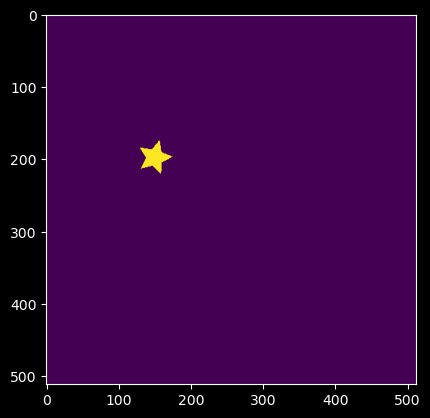

In [8]:
import cv2
import numpy as np
from tqdm import tqdm
data_dir = '/data2/CHAOS_test.npy'
import numpy as np
import matplotlib.pyplot as plt
data = np.load(data_dir, allow_pickle=True).item()

def resize_image_batch(image_array, target_size=(256, 256), is_mask=False):
    """
    Resizes a batch of images in a NumPy array from (N, H, W) to (N, new_H, new_W).
    
    Args:
        image_array (np.ndarray): The array of images to resize.
        target_size (tuple): The target (width, height).
        is_mask (bool): If True, use nearest-neighbor interpolation suitable for masks.
                        Otherwise, use INTER_AREA, which is good for downsampling images.
                        
    Returns:
        np.ndarray: The array of resized images.
    """
    if image_array.shape[1:3] == target_size[::-1]:
        print("Images are already at the target size.")
        return image_array
    if image_array.dtype == bool:
        image_array = image_array.astype(np.uint8)

    interpolation = cv2.INTER_NEAREST if is_mask else cv2.INTER_AREA
    
    resized_images = [cv2.resize(img, target_size, interpolation=interpolation) for img in tqdm(image_array, desc=f"Resizing to {target_size}")]
    
    return np.array(resized_images)

# --- Example of how to use it with your data ---

# Assuming 'data' is your loaded dictionary
# Resize the tumor images
tumor_img_512 = data['ood_large_moderate_randomized_inpainted_warped']
tumor_img_256 = resize_image_batch(tumor_img_512, target_size=(256, 256), is_mask=False)


# Resize the tumor masks (using is_mask=True)
tumor_mask_512 = data['ood_large_moderate_randomized_inpainted_labels_warped']
tumor_mask_256 = resize_image_batch(tumor_mask_512, target_size=(256, 256), is_mask=True)

# Resize the body masks (using is_mask=True)
body_mask_512 = data['ood_large_moderate_randomized_inpainted_masks_warped']
body_mask_256 = resize_image_batch(body_mask_512, target_size=(256, 256), is_mask=True)
print(tumor_mask_512.shape)
print(tumor_mask_256.shape)
# Resize the star images

# star_mask_512 = data['ood_star_new_labels_warped']
# plt.imshow(star_mask_512[0])
# print(star_mask_512.shape)
# star_mask_256 = resize_image_batch(star_mask_512, target_size=(256, 256), is_mask=True)

# body_mask_star_512 = data['ood_star_new_mask_warped']
# body_mask_star_256 = resize_image_batch(body_mask_star_512, target_size=(256, 256), is_mask=True)

star_img_512 = data['ood_star_new_2_warped']
star_img_256 = resize_image_batch(star_img_512, target_size=(256, 256), is_mask=False)

star_mask_512 = data['ood_star_new_2_labels_warped']
plt.imshow(star_mask_512[0])
print(star_mask_512.shape)
star_mask_256 = resize_image_batch(star_mask_512, target_size=(256, 256), is_mask=True)

body_mask_star_512 = data['ood_star_new_2_mask_warped']
body_mask_star_256 = resize_image_batch(body_mask_star_512, target_size=(256, 256), is_mask=True)

body_mask_512_img = data['id_new_mask_warped']
body_mask_256_img = resize_image_batch(body_mask_512_img, target_size=(256, 256), is_mask=True)

# You can now update your data dictionary or use the new variables
# data['ood_large_moderate_randomized_inpainted_warped_256'] = tumor_img_256
# data['ood_large_moderate_randomized_inpainted_labels_warped_256'] = tumor_mask_256
# data['ood_large_moderate_randomized_inpainted_masks_warped_256'] = body_mask_256

print("\nResizing complete.")
print(f"Original image shape: {tumor_img_512.shape}")
print(f"Resized image shape:  {tumor_img_256.shape}")
print(f"Original mask shape: {tumor_mask_512.shape}")
print(f"Resized mask shape:  {tumor_mask_256.shape}")

In [9]:
import gc

# Delete the large 512x512 arrays after creating the 256x256 versions
del tumor_img_512
del tumor_mask_512
del body_mask_512
del star_mask_512
del body_mask_star_512
del star_img_512
del data
# del id_measurement
# del val_measurement
# del cal_measurement
# del ood_artifacts
# del ood_artifacts_star


# Force garbage collection to free up memory
gc.collect()

print("Large 512x512 arrays have been deleted and memory has been reclaimed.")

Large 512x512 arrays have been deleted and memory has been reclaimed.


In [10]:
base_path = "/data/akheirandish3/PaDIS_results/"
runs = [1]  # Runs to average over
folder_names = [
    # "Dps_24_NEW_Tumor_second_try"
    "Dps_24_NEW_OOD_default_medium_full_intermediate_steps"
    
]
pattern = ""
ood_artifacts = {}
for run in range(1, 2, 3):
    artifacts = load_all_artifacts_from_folder(
        base_path=base_path,
        pattern=pattern,
        run=run,
        data_type="measurement_updates",
        folder_name=folder_names[0]
    )
    # Merge artifacts from this folder into the main dictionary
    ood_artifacts.update(artifacts)


Found 100 artifacts in /data/akheirandish3/PaDIS_results/Dps_24_NEW_OOD_default_medium_full_intermediate_steps/run_1
Artifact IDs: ['image_0000_mean', 'image_0001_mean', 'image_0002_mean', 'image_0003_mean', 'image_0004_mean', 'image_0005_mean', 'image_0006_mean', 'image_0007_mean', 'image_0008_mean', 'image_0009_mean', 'image_0010_mean', 'image_0011_mean', 'image_0012_mean', 'image_0013_mean', 'image_0014_mean', 'image_0015_mean', 'image_0016_mean', 'image_0017_mean', 'image_0018_mean', 'image_0019_mean', 'image_0020_mean', 'image_0021_mean', 'image_0022_mean', 'image_0023_mean', 'image_0024_mean', 'image_0025_mean', 'image_0026_mean', 'image_0027_mean', 'image_0028_mean', 'image_0029_mean', 'image_0030_mean', 'image_0031_mean', 'image_0032_mean', 'image_0033_mean', 'image_0034_mean', 'image_0035_mean', 'image_0036_mean', 'image_0037_mean', 'image_0038_mean', 'image_0039_mean', 'image_0040_mean', 'image_0041_mean', 'image_0042_mean', 'image_0043_mean', 'image_0044_mean', 'image_0045_m

In [11]:
base_path = "/data/akheirandish3/PaDIS_results/"
key_word = 'default_medium'
runs = [1]  # Runs to average over
folder_names = [
    # "Dps_24_NEW_Tumor_second_try"
    f"Dps_24_NEW_OOD_{key_word}_full_intermediate_steps"
    
]
pattern = ""
ood_artifacts = {}
for run in range(1, 2, 3):
    artifacts = load_all_artifacts_from_folder(
        base_path=base_path,
        pattern=pattern,
        run=run,
        data_type="measurement_updates",
        folder_name=folder_names[0]
    )
    # Merge artifacts from this folder into the main dictionary
    ood_artifacts.update(artifacts)



Found 100 artifacts in /data/akheirandish3/PaDIS_results/Dps_24_NEW_OOD_default_medium_full_intermediate_steps/run_1
Artifact IDs: ['image_0000_mean', 'image_0001_mean', 'image_0002_mean', 'image_0003_mean', 'image_0004_mean', 'image_0005_mean', 'image_0006_mean', 'image_0007_mean', 'image_0008_mean', 'image_0009_mean', 'image_0010_mean', 'image_0011_mean', 'image_0012_mean', 'image_0013_mean', 'image_0014_mean', 'image_0015_mean', 'image_0016_mean', 'image_0017_mean', 'image_0018_mean', 'image_0019_mean', 'image_0020_mean', 'image_0021_mean', 'image_0022_mean', 'image_0023_mean', 'image_0024_mean', 'image_0025_mean', 'image_0026_mean', 'image_0027_mean', 'image_0028_mean', 'image_0029_mean', 'image_0030_mean', 'image_0031_mean', 'image_0032_mean', 'image_0033_mean', 'image_0034_mean', 'image_0035_mean', 'image_0036_mean', 'image_0037_mean', 'image_0038_mean', 'image_0039_mean', 'image_0040_mean', 'image_0041_mean', 'image_0042_mean', 'image_0043_mean', 'image_0044_mean', 'image_0045_m

In [12]:

data_dir = '/data2/CHAOS_test_ablation.npy'
import numpy as np
import matplotlib.pyplot as plt
data = np.load(data_dir, allow_pickle=True).item()
name_file = f"ood_tumor_{key_word}"
data_k = data[f'{name_file}']
body_mask_256 = data[f'{name_file}_masks'][:,::2,::2]
tumor_mask_256 = data[f'{name_file}_labels'][:,::2,::2]>1
print(body_mask_256.shape, tumor_mask_256.shape)
# plt.imshow(data_k[0],cmap='gray')
# plt.figure()
# plt.imshow(body_mask_256[0],cmap='gray')
# plt.figure()
# plt.imshow(tumor_mask_256[0],cmap='gray')

(100, 256, 256) (100, 256, 256)


In [19]:
# ood_results_list = []
# patch_size = 4
# # artifact_ids_to_avoid = [
# #     "0759_30_0233_syn01_mean",
# #     "0761_30_0226_syn00_mean",
# #     "0761_30_0226_syn02_mean",
# #     "0767_2_0045_syn02_mean",
# #     "0779_23_0057_syn01_mean",
# #     "0779_23_0057_syn02_mean",
# #     "0780_16_0025_syn00_mean",
# #     "0780_16_0025_syn01_mean",
# #     "0780_16_0025_syn02_mean",
# # ]
# auc_best = 0
# best_window_start = 0
# best_window_end = 0
# for window_start in range(0,96,5):
#     for window_end in range(window_start+5,101,5):
from sklearn.metrics import roc_curve, auc
# tumor_mask_256 = star_mask_256
# body_mask_256 = body_mask_star_256
# ood_artifacts = ood_artifacts_star
patch_size = 2
auc_list = []
window_start = 65
window_end = 85
for artifact_id in ood_artifacts:
    # If it exists, retrieve the numpy array
    # if artifact_id in artifact_ids_to_avoid:
    #     continue
    ood_artifact = {}
    ood_artifact[artifact_id] = ood_artifacts[artifact_id]
    artifact_id_num = artifact_id.split('_')[1]
    # print("Processing artifact id: ", np.uint(artifact_id_num))
    idx = np.uint(artifact_id_num)
    mask_test = tumor_mask_256[idx]>0
    # print("Mask test shape before erosion: ", mask_test.shape)
    # mask_test = plt.imread(f"/data2/akheirandish3/aligned_images_and_masks/out_of_distribution/masks_tumor/{artifact_id.split('_mean')[0]}.png")
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    # 2. Define the number of iterations. More iterations will make the mask smaller.
    # iterations = 2

    # 3. Apply the erosion to the mask
    # eroded_mask = cv2.erode(mask_test, kernel, iterations=iterations)

    mask_test = mask_test.reshape(256//patch_size,patch_size,256//patch_size,patch_size).mean(axis=(1,3))>0
    # mask_test = eroded_mask.reshape(256//patch_size,patch_size,256//patch_size,patch_size).mean(axis=(1,3))>0
    # mask_body = plt.imread(f"/data2/akheirandish3/aligned_images_and_masks/out_of_distribution/masks_body/{artifact_id.split('_mean')[0]}.png")
    mask_body = body_mask_256[idx]>0
        # 2. Define the number of iterations. More iterations will make the mask smaller.
    mask_body = mask_body.reshape(256//patch_size,patch_size,256//patch_size,patch_size).mean(axis=(1,3))>0
    ood_results = analyze_patch_correlation_test_here(ood_artifact, one_sigma, window_start=window_start, window_end=window_end, patch_sizes = [patch_size], sigma_power = 0.5, kennel_size=0, angles=0, Gaussian=True)
    # ood_results_list.append(ood_results['artifacts'][artifact_id]['patch_norms'].max())
    all_patches = ood_results['artifacts'][artifact_id]['patch_norms']#* mask_body
    scores = all_patches[mask_body]
    labels = mask_test[mask_body]
    # print("Scores shape: ", all_patches.shape, " Labels shape: ", labels.shape)
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    auc_list.append(roc_auc)
print("AUC for window ", window_start, window_end, " is: ", np.array(auc_list).mean())



patch_size = 2
auc_list = []
window_start = 0
window_end = 100
for artifact_id in ood_artifacts:
    # If it exists, retrieve the numpy array
    # if artifact_id in artifact_ids_to_avoid:
    #     continue
    ood_artifact = {}
    ood_artifact[artifact_id] = ood_artifacts[artifact_id]
    artifact_id_num = artifact_id.split('_')[1]
    # print("Processing artifact id: ", np.uint(artifact_id_num))
    idx = np.uint(artifact_id_num)
    mask_test = tumor_mask_256[idx]>0
    # print("Mask test shape before erosion: ", mask_test.shape)
    # mask_test = plt.imread(f"/data2/akheirandish3/aligned_images_and_masks/out_of_distribution/masks_tumor/{artifact_id.split('_mean')[0]}.png")
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    # 2. Define the number of iterations. More iterations will make the mask smaller.
    # iterations = 2

    # 3. Apply the erosion to the mask
    # eroded_mask = cv2.erode(mask_test, kernel, iterations=iterations)

    mask_test = mask_test.reshape(256//patch_size,patch_size,256//patch_size,patch_size).mean(axis=(1,3))>0
    # mask_test = eroded_mask.reshape(256//patch_size,patch_size,256//patch_size,patch_size).mean(axis=(1,3))>0
    # mask_body = plt.imread(f"/data2/akheirandish3/aligned_images_and_masks/out_of_distribution/masks_body/{artifact_id.split('_mean')[0]}.png")
    mask_body = body_mask_256[idx]>0
        # 2. Define the number of iterations. More iterations will make the mask smaller.
    mask_body = mask_body.reshape(256//patch_size,patch_size,256//patch_size,patch_size).mean(axis=(1,3))>0
    ood_results = analyze_patch_correlation_test_here(ood_artifact, one_sigma, window_start=window_start, window_end=window_end, patch_sizes = [patch_size], sigma_power = 0.5, kennel_size=0, angles=0, Gaussian=True)
    # ood_results_list.append(ood_results['artifacts'][artifact_id]['patch_norms'].max())
    all_patches = ood_results['artifacts'][artifact_id]['patch_norms']#* mask_body
    scores = all_patches[mask_body]
    labels = mask_test[mask_body]
    # plt.imshow(all_patches)
    # break
    # print("Scores shape: ", all_patches.shape, " Labels shape: ", labels.shape)
    fpr, tpr, thresholds = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    auc_list.append(roc_auc)
print("AUC for window ", window_start, window_end, " is: ", np.array(auc_list).mean())
#         print(window_start, window_end, np.array(auc_list).mean())

#         print(window_start, window_end, np.array(auc_list).mean())
#         if auc_best < np.array(auc_list).mean():
#             auc_best = np.array(auc_list).mean()
#             best_window_start = window_start
#             best_window_end = window_end
#             print("New best AUC: ", auc_best, " at window: ", best_window_start, best_window_end)  
#     # plt.plot(auc_list)

AUC for window  65 85  is:  0.6726710459015146
AUC for window  0 100  is:  0.5968284679837075
